![banner](../../docs/figs/brand_identity/banner.png)

<img src="../../docs/figs/ml.png" width="80%">

## Today we will try to train a Linear Regression model & Decision Tree Model!
#### In this tutorial, we'll build simple Machine Learning models to predict *house prices*

<img src="../../docs/figs/loss_target.png" width="100%">

In [4]:
# import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## A. Linear Regression Model (Regression)

### 1. Load & clean the dataset

In [5]:
# read dataset
df = pd.read_csv("housing_price_california.csv", index_col=0)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [6]:
# Drop rows with missing values (if any)
df = df.dropna()
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### 2. Separate Input & Output

In [7]:
X = df.drop("Target", axis=1) # features: remove "Target" column, axis=0 (rows), axis=1 (columns)
y = df["Target"] # extracting "Target" column
display(X)
display(y)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Target, Length: 20640, dtype: float64

### 3. Normalization

Some machine learning models — like *Linear Regression* — are sensitive to the *scale of the features*.

For example, imagine one feature is "income" (ranging from 0 to 100,000) and another is "house age" (ranging from 1 to 50). The model might *focus more on income* just because it has larger numbers, not because it's more important.

*Normalization* solves this by rescaling all features to a similar range, like 0 to 1.  
This helps the model treat all features fairly during training.

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X) # fit + transform. fit: calculate data stats; transform: rescale

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns) # columns = assign labels to columns; .columns extract column labels from dataset

print("Feature ranges after normalization:")
for col in X.columns:
    col_min = X_scaled_df[col].min()
    col_max = X_scaled_df[col].max()
    print(f"{col}: {col_min:.3f} to {col_max:.3f}")

Feature ranges after normalization:
MedInc: 0.000 to 1.000
HouseAge: 0.000 to 1.000
AveRooms: 0.000 to 1.000
AveBedrms: 0.000 to 1.000
Population: 0.000 to 1.000
AveOccup: 0.000 to 1.000
Latitude: 0.000 to 1.000
Longitude: 0.000 to 1.000


### 4. Train-test split

`test_size=0.2` 20% of the data will be used for testing, 80% for training

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### 5. Train Model

In [10]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 6. Test model

**Mean Squared Error (MSE)**: 
- the average squared difference between the *actual values* and the *predicted values*
- Lower MSE = better model performance

**R-squared (R^2)**:
- indicates the proportion of *variance* in the target variable explained by the model (How much does the model eliminate baseline error)
- 1 = perfect prediction, 0 = no variance

In [11]:
# Make Predictions
y_pred = lr_model.predict(X_test)

# Evaluate the Model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.555891598695244
R² Score: 0.5757877060324511


### 7. Visualization

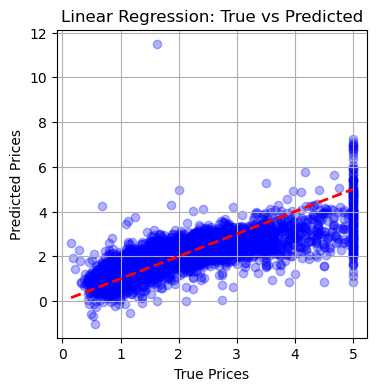

In [33]:
# Scatter plot: True vs Predicted
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred, alpha=0.3, c='blue')

# plotting the target line ([x_start, x_end][y_start, y_end])
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2) 

plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: True vs Predicted")
plt.grid(True)
plt.show()

### 8. Use it!

In [81]:
new_house = np.array([[8.3, 41.0, 6.9, 1.0, 322.0, 2.5, 37.8, -122.2]]) # Raw data
new_house_scaled = scaler.transform(new_house)

prediction = lr_model.predict(new_house_scaled)
print(f"Predicted Price: ${prediction[0]:.2f}")

Predicted Price: $3.64


## B. Decision Tree Model (Classification + Regres)

- The decision tree splits the data into smaller groups based on feature values.  
- At each step, it picks the feature and split point that best separate the data to minimize prediction error.  
- The tree continues splitting until stopping criteria are met (like max depth or minimum samples).  
- It predicts new data by following the splits down the tree to a leaf node, which gives the output value.

Unlike Linear Regression, Decision Trees do not require normalized data because they rely on thresholds, not on distances or scales.

<img src="../../docs/figs/dt.png" width="50%">

### 1. Train-test split

In [15]:
from sklearn.tree import DecisionTreeRegressor

# Use original (non-normalized) data for Decision Tree
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. Train Model

In [16]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_orig, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### 3. Test Model

In [17]:
# Predict on test set
y_pred_dt = dt_model.predict(X_test_orig)

# Evaluate
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Decision Tree R^2: {r2_dt:.4f}")

Decision Tree MSE: 0.4952
Decision Tree R^2: 0.6221


### 4. Visualization

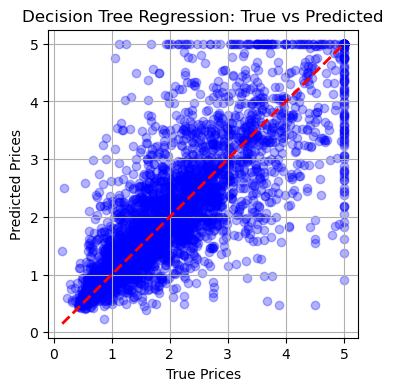

In [32]:
# Scatter plot: True vs Predicted
plt.figure(figsize=(4, 4))
plt.scatter(y_test, y_pred_dt, alpha=0.3, c='blue')

# plotting the target line ([x_start, x_end][y_start, y_end])
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)

plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("Decision Tree Regression: True vs Predicted")
plt.grid(True)
plt.show()

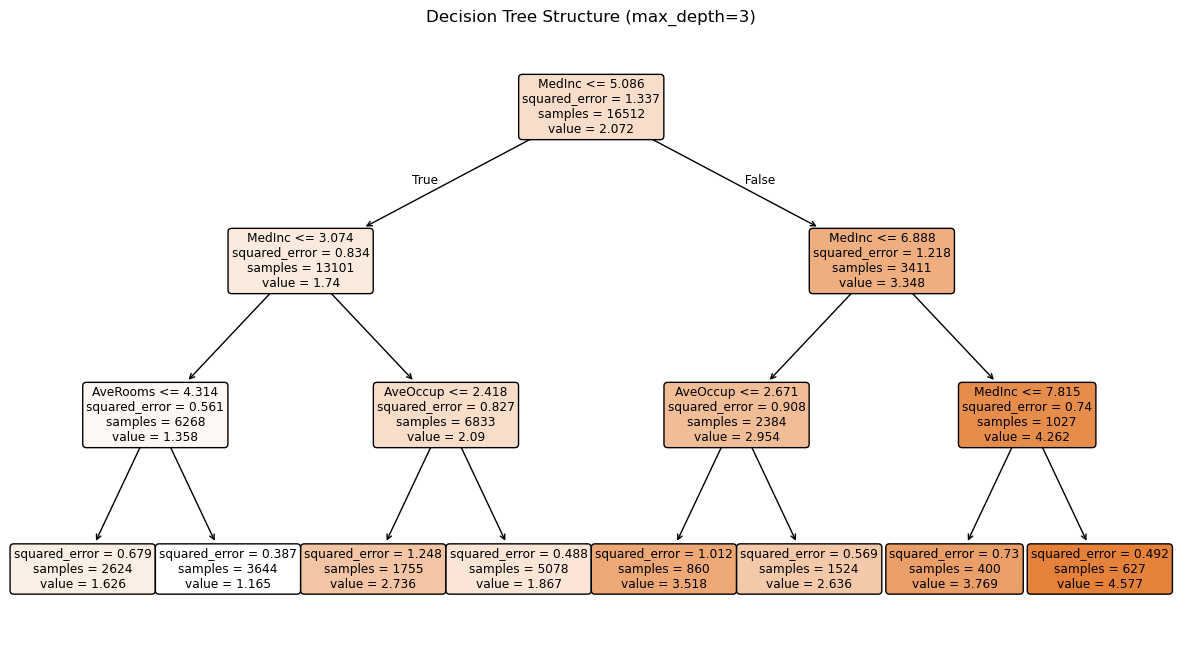

In [19]:
from sklearn.tree import plot_tree

# Train a shallow decision tree with max depth = 3 for easy visualization
dt_model_small = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model_small.fit(X_train_orig, y_train)

# Plot the shallow tree structure
plt.figure(figsize=(15,8))
plot_tree(
    dt_model_small,
    filled=True,               # Fill nodes with colors
    feature_names=X.columns,   # Show feature names on nodes
    rounded=True               # Rounded corners for nodes
)
plt.title("Decision Tree Structure (max_depth=3)")
plt.show()

#### How to read the Decision Tree plot:
- Each box = a decision node
- Condition inside splits data into left (True) and right (False) branches.
- Samples: number of data points reaching that node.
- Value: predicted output (average target) at that node.
- Leaves: final predictions with no further splits.

### 5. Use it!

In [97]:
new_house = np.array([[8.3, 41.0, 6.9, 1.0, 322.0, 2.5, 37.8, -122.2]]) # Raw data
new_house_scaled = scaler.transform(new_house)

pd_new_house_scaled = pd.DataFrame(new_house_scaled, columns=X.columns)
prediction = dt_model.predict(pd_new_house_scaled)

print(f"Predicted Price: ${prediction[0]:.2f}")

Predicted Price: $1.38
